<a href="https://colab.research.google.com/github/Safayat777/my_new/blob/main/EfficientNet_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install tensorflow

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

In [9]:
dataset_path = "/content/drive/MyDrive/DataSet/ArsenicSkinImageBD"

In [13]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dataset_path ,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    dataset_path ,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 8892 images belonging to 2 classes.
Found 8892 images belonging to 2 classes.


In [14]:
input_layer = Input(shape=(224,224,3))

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Flatten()(x)

cnn_features = Dense(256,activation='relu')(x)

In [15]:
efficientnet = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

efficientnet.trainable = False

y = efficientnet.output
y = GlobalAveragePooling2D()(y)
y = BatchNormalization()(y)

efficient_features = Dense(256,activation='relu')(y)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
combined = Concatenate()([cnn_features, efficient_features])

z = Dense(256,activation='relu')(combined)
z = Dropout(0.5)(z)

output = Dense(train_generator.num_classes,activation='softmax')(z)

model = Model(inputs=input_layer,outputs=output)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 30,298,981 (115.58 MB)

 Trainable params: 26,246,402 (100.12 MB)

 Non-trainable params: 4,052,579 (15.46 MB)

In [18]:
EPOCHS = 25

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 1902s 6s/step - accuracy: 0.6424 - loss: 5.5619 - val_accuracy: 0.5000 - val_loss: 24.5890
Epoch 2/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 207s 744ms/step - accuracy: 0.7476 - loss: 0.5181 - val_accuracy: 0.6531 - val_loss: 1.2736
Epoch 3/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 208s 746ms/step - accuracy: 0.7900 - loss: 0.4512 - val_accuracy: 0.5959 - val_loss: 1.2861
Epoch 4/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 207s 745ms/step - accuracy: 0.8295 - loss: 0.4035 - val_accuracy: 0.7521 - val_loss: 0.5363
Epoch 5/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 211s 758ms/step - accuracy: 0.8247 - loss: 0.3867 - val_accuracy: 0.7993 - val_loss: 0.4516
Epoch 6/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 207s 745ms/step - accuracy: 0.8423 - loss: 0.3469 - val_accuracy: 0.6756 - val_loss: 0.9670
Epoch 7/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 207s 745ms/step - accuracy: 0.8314 - loss: 0.3808 - val_accuracy: 0.5155 - val_loss: 9.0287
Epoch 8/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 206s 742ms/step - accuracy: 0.8520 - 

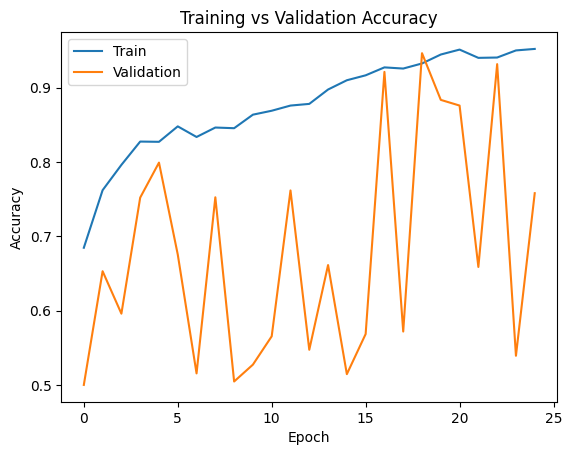

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

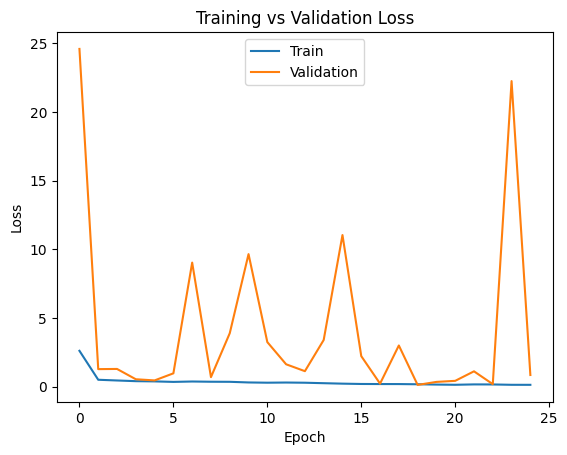

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()